In [112]:
# 1. predict Yolo objects

import os
from pathlib import Path
from ultralytics import YOLO
import cv2 as cv

# dir = 'data/cars_001'

# dir = 'data/cars_002_learn_2/' + 'train/images'
# dir = 'data/cars_002_val'
# dir = 'data/cars_002_learn_2/val/images'

dir = 'data/cars_002_learn_3/' + 'val/images'
output_folder_name = 'out/result'

# model = YOLO("yolo11n.pt")
HOME = '/home/jovyan' + '/'
models_dir = HOME + 'work/test_VK/test_project_1/runs/detect/'
model = YOLO(models_dir + "train24" + "/weights/best.pt")

file_count = 0

file_1_name_list = os.listdir(dir)
for file_1_name in file_1_name_list:
    if file_1_name == '.ipynb_checkpoints':
        continue
    # print(f'{file_1_name}')

    file_1_path = dir + '/' + file_1_name
    file_2_name_list = os.listdir(file_1_path)
    
    for file_2_name in file_2_name_list:
        if file_2_name == '.ipynb_checkpoints':
            continue
        print(f'{file_1_name}')
            
        # if file_count >= 4:
        #     break
        # if not file_2_name.startswith('Changan_CS55_E-Rock_IMG001'):
        #     continue
        
        print(f'    {file_2_name}')
            

        file_2_path = file_1_path + '/' + file_2_name
        # 1
        # results = model(file_2_path)
        # 1.1
        results = model.predict(file_2_path, 
                imgsz=1600
        )
        # 2
        # results = model.predict(file_2_path,
        #         # visualize='images/debug')
        #         visualize=True)

        # 3
        img = cv.imread(file_2_path)  # shape: (H, W, 3) BGR
        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Конвертируем в RGB
        
        import util

        results = util.predict_img(img, model)
        
        # Process results list
        for result in results:
            boxes = result.boxes  # Boxes object for bounding box outputs
            masks = result.masks  # Masks object for segmentation masks outputs
            keypoints = result.keypoints  # Keypoints object for pose outputs
            probs = result.probs  # Probs object for classification outputs
            obb = result.obb  # Oriented boxes object for OBB outputs
            # result.show()  # display to screen

            # out_file_path = Path(result.path).name
            out_file_dir  = output_folder_name + "/" + file_1_name
            out_file_path = out_file_dir + '/' + file_2_name + '.jpg'
            
            os.makedirs(out_file_dir, exist_ok=True)
            print(f'save {out_file_path}')
            # 1
            # result.save(output_folder_name + "/" + out_file_path)  # save to disk

            # shifted with padding
            img_out = util.show_results_img(result)
            cv.imwrite(out_file_path, img_out)

        file_count += 1

05_BYD_SEAL_U_DM-i
    Seal-u-dmi-exterior-04-blue-xl.jpg

image 1/1 /home/jovyan/work/test_VK/test_project_1/data/cars_002_learn_3/val/images/05_BYD_SEAL_U_DM-i/Seal-u-dmi-exterior-04-blue-xl.jpg: 896x1600 1 05_BYD_SEAL_U_DM-i, 3.3ms
Speed: 3.8ms preprocess, 3.3ms inference, 0.6ms postprocess per image at shape (1, 3, 896, 1600)

0: 2048x2048 1 05_BYD_SEAL_U_DM-i, 8.3ms
Speed: 10.0ms preprocess, 8.3ms inference, 0.6ms postprocess per image at shape (1, 3, 2048, 2048)
save out/result/05_BYD_SEAL_U_DM-i/Seal-u-dmi-exterior-04-blue-xl.jpg.jpg
05_BYD_SEAL_U_DM-i
    seal_u_interior_10.jpg

image 1/1 /home/jovyan/work/test_VK/test_project_1/data/cars_002_learn_3/val/images/05_BYD_SEAL_U_DM-i/seal_u_interior_10.jpg: 1088x1600 1 05_BYD_SEAL_U_DM-i, 3.6ms
Speed: 3.0ms preprocess, 3.6ms inference, 0.5ms postprocess per image at shape (1, 3, 1088, 1600)

0: 2048x2048 1 07_Chery_Arrizo_5, 8.1ms
Speed: 6.0ms preprocess, 8.1ms inference, 0.6ms postprocess per image at shape (1, 3, 2048, 2048)
save

data.shape (32, 512, 512)
2
channel 1 data_2.shape (512, 512)


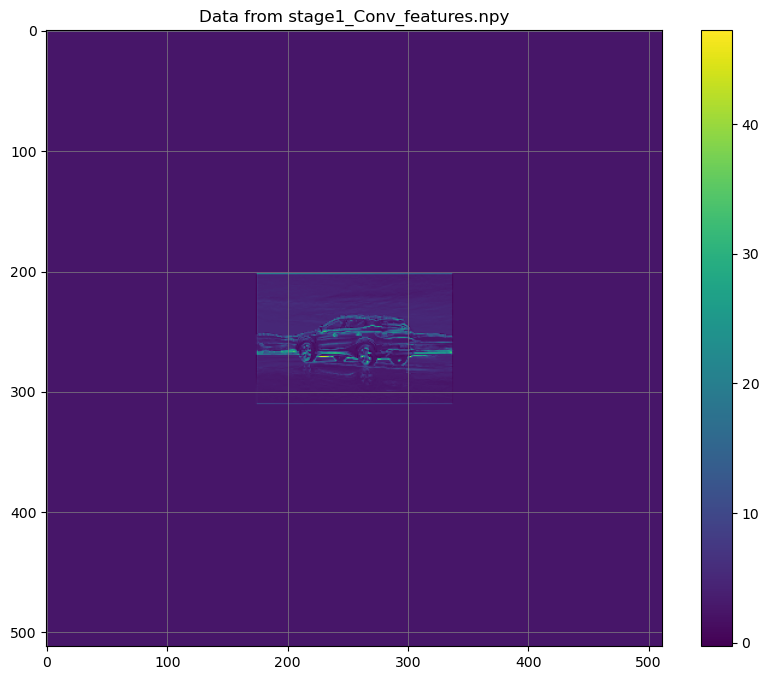

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt


def visualize_npy_data(npy_file, num_maps=16):
    """Визуализация feature maps из .npy файла"""
    
    # Загружаем данные
    data = np.load(npy_file)

    print(f'data.shape {data.shape}')
    
    # Проверяем формат данных
    if len(data.shape) == 4:  # [batch, channels, height, width]
        # Берем первый батч
        feature_maps = data[0]
        
        # Ограничиваем количество карт для визуализации
        num_to_show = min(num_maps, feature_maps.shape[0])
        
        # Создаем визуализацию
        fig, axes = plt.subplots(4, 4, figsize=(12, 12))
        axes = axes.ravel()
        
        for i in range(num_to_show):
            if i < len(axes):
                # Нормализуем для визуализации
                img = feature_maps[i]
                img = (img - img.min()) / (img.max() - img.min())
                
                axes[i].imshow(img, cmap='viridis')
                axes[i].set_title(f'Feature Map {i}')
                axes[i].axis('off')
        
        plt.suptitle(f'Feature Maps from {os.path.basename(npy_file)}')
        plt.tight_layout()
        plt.show()
        
    elif len(data.shape) == 3:  # [channels, height, width] или [height, width, channels]
        # Визуализируем как изображение
        plt.figure(figsize=(10, 8))
        
        if data.shape[0] == 3:  # RGB-like
            print('1')
            img = np.transpose(data, (1, 2, 0))
            plt.imshow(img)
        else:
            print('2')
            # # Берем среднее по каналам
            # img = data.mean(axis=0)
            # plt.imshow(img, cmap='hot')

            # 2
            channel_i = 1
            data_2 = data[channel_i]
            print(f'channel {channel_i} data_2.shape {data_2.shape}')
            img = np.transpose(data_2, (0, 1))
            plt.imshow(img)
            plt.grid(True, color='gray', linewidth=0.5)
        
        plt.title(f'Data from {os.path.basename(npy_file)}')
        plt.colorbar()
        plt.show()

HOME = '/home/jovyan' + '/'
# dir = HOME + 'work/test_VK/test_project_1/runs/detect/predict2/02_BYD_ATTO_3_rear-left-view-121/'
dir = HOME + 'work/test_VK/test_project_1/runs/detect/predict2/image0/'
# visualize_npy_data(dir + 'stage0_Conv_features.npy')
visualize_npy_data(dir + 'stage1_Conv_features.npy')
# visualize_npy_data(dir + 'stage4_C3k2_features.npy')
# visualize_npy_data(dir + 'stage10_C2PSA_features.npy')
# visualize_npy_data(dir + 'stage21_Concat_features.npy')
# visualize_npy_data(dir + 'stage22_C3k2_features.npy')

In [108]:
# 2. save Yolo anns

import os
from pathlib import Path
from ultralytics import YOLO


# dir = 'data/cars_001'
# dir = 'data/cars_002'
# dir = 'data/cars_002_learn_2/train/images'
# dir = 'data/cars_002_learn_2/val/images'

dir = 'data/cars_002_learn_3'
# dir = 'data/cars_002_learn_2'
# val make labels
# dir = 'data/cars_001_val'
# dir = 'data/cars_002_val'
out_folder_name = 'out'

# COCO DS
model = YOLO("yolo11n.pt")

label_i_dict = {
    '01_Bestune_T77':         0,
    '02_BYD_ATTO_3':          1,
    '03_BYD_DOLPHIN':         2,
    '04_BYD_SEAL':            3,
    '05_BYD_SEAL_U_DM-i':     4,
    '06_Changan_CS55_E-Rock': 5,
    '07_Chery_Arrizo_5':      6,
    '08_Chery_Arrizo_8':      7,
    '09_Chery_Arrizo_GX':     8,
    '10_Chery_Tiggo_3x':      9,
    '11_GAC_Emkoo':           10,
    '12_GAC_Empow':           11,
    '13_Chery_Tiggo_7L':      12,
    '14_Chery_Tiggo_8_Pro_Max': 13,
    '15_Chery_Tiggo_4':       14,
    '16_Chery_Tiggo_9':       15,
}


def calc_img_dict(dir):
    img_stat_dict = {}
    
    file_1_name_list = os.listdir(dir)
    for file_1_name in file_1_name_list:
        if file_1_name == '.ipynb_checkpoints':
            continue
        # print(f'{file_1_name}')
    
        file_1_path = dir + '/' + file_1_name
        
        file_2_name_list = os.listdir(file_1_path)
        
        for file_2_name in file_2_name_list:
            if file_2_name == '.ipynb_checkpoints':
                continue
            
    
            file_2_path = file_1_path + '/' + file_2_name
    
            # change
            label_i = label_i_dict[file_1_name]
            cls = label_i
            
            img_size = img_stat_dict.get(cls)
            if img_size is None:
                img_size = 0
            img_size = img_size+1
            img_stat_dict.update({cls: img_size})
    
    return img_stat_dict

img_stat_dict_train = calc_img_dict(dir + '/train/images')

img_stat_dict_val = calc_img_dict(dir + '/val/images')

print(f'label:\ttrain\tval\ttotal')
for key in sorted(img_stat_dict_train.keys()):
    img_size_train = img_stat_dict_train.get(key)
    img_size_val   = img_stat_dict_val.get(key)

    label = key + 1
    print(f'{label}:\t{img_size_train}\t{img_size_val}\t{img_size_train+img_size_val}')

label:	train	val	total
1:	175	16	191
2:	187	16	203
3:	96	16	112
4:	71	16	87
5:	86	16	102
6:	81	16	97
7:	76	16	92
8:	58	16	74
9:	54	16	70
10:	48	16	64
11:	95	16	111
12:	61	16	77
13:	90	16	106
14:	69	16	85
15:	90	16	106
16:	73	16	89


In [99]:
from ultralytics import YOLO

# base Yolo
# model_path = "yolo11n.pt"
model_path = 'runs/detect/train23/weights/best.pt'
model = YOLO(model_path)

results = model.train(
    data="data/cars_002_learn_3/cars_2.yaml",
    # epochs=70,
    epochs=15,
    # imgsz=1600,
    imgsz=1024,
    # imgsz=860,
    # batch=2,
    batch=4,
    workers=0,
    patience=20,    
    # # new params
    translate=0,   # random clip with factor
    mosaic=0,      # clip 4 images into 1 (WTF ?)
    scale=0.25,
    # save_period=1
)

New https://pypi.org/project/ultralytics/8.3.226 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.167 🚀 Python-3.11.7 torch-2.9.0.dev20250714+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15837MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/cars_002_learn_3/cars_2.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/train23/weights/best.pt, momentum=0.937, mosaic=0, multi_scale=False,

train: Scanning /home/jovyan/work/test_VK/test_project_1/data/cars_002_learn_3/train/labels/01_Bestune_T77... 1388 images, 22 backgrounds, 0 corrupt: 100%|██████████| 1410/1410 [00:02<00:00, 505.97it/s]

train: New cache created: /home/jovyan/work/test_VK/test_project_1/data/cars_002_learn_3/train/labels/01_Bestune_T77.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4982.7±1205.3 MB/s, size: 162.6 KB)



val: Scanning /home/jovyan/work/test_VK/test_project_1/data/cars_002_learn_3/val/labels/01_Bestune_T77.cache... 256 images, 0 backgrounds, 0 corrupt: 100%|██████████| 256/256 [00:00<?, ?it/s]


Plotting labels to runs/detect/train24/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.0005, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 1024 train, 1024 val
Using 0 dataloader workers
Logging results to runs/detect/train24
Starting training for 15 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      15/15      4.14G     0.2004     0.1989     0.7688          2       1024: 100%|██████████| 353/353 [00:43<00:00,  8.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:03<00:00,  9.97it/s]

                   all        256        256      0.874      0.808      0.851      0.834



15 epochs completed in 0.194 hours.
Optimizer stripped from runs/detect/train24/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train24/weights/best.pt, 5.5MB

Validating runs/detect/train24/weights/best.pt...
Ultralytics 8.3.167 🚀 Python-3.11.7 torch-2.9.0.dev20250714+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15837MiB)
YOLO11n summary (fused): 100 layers, 2,585,272 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:03<00:00,  9.88it/s]


                   all        256        256      0.845      0.826      0.853      0.835
        01_Bestune_T77         16         16      0.744      0.911      0.904      0.904
         02_BYD_ATTO_3         16         16      0.898      0.812      0.856      0.856
        03_BYD_DOLPHIN         16         16       0.98          1      0.995      0.989
           04_BYD_SEAL         16         16      0.871          1      0.991       0.98
    05_BYD_SEAL_U_DM-i         16         16          1      0.808      0.911      0.911
06_Changan_CS55_E-Rock         16         16      0.852      0.718      0.903      0.869
     07_Chery_Arrizo_5         16         16      0.832      0.938      0.965      0.965
     08_Chery_Arrizo_8         16         16       0.75      0.812      0.817      0.733
    09_Chery_Arrizo_GX         16         16      0.914      0.668      0.763      0.746
     10_Chery_Tiggo_3x         16         16          1      0.681      0.899      0.859
          11_GAC_Emko

In [88]:
dir_1 = '/home/jovyan/work/test_VK/test_project_1' 

# !rm -r {dir_1}/pymp-*
# !rm -r {dir_1}/data/cars_002_learn/train/*
# !rm -r {dir_1}/data/cars_002_learn_2/train/*
# !rm -r {dir_1}/data/cars_002_learn_2/val/images/*
# !rm -r {dir_1}/data/cars_002_learn_2/val/labels/*

# check_dir = f'{dir_1}/out/check_label'
# !rm -r {check_dir}/images/*
# !rm -r {check_dir}/labels/*

# !cp -r {dir_1}/out/images/01_Bestune_T77* {dir_1}/data/cars_002_learn_2/train/images/01_Bestune_T77
# !cp -r {dir_1}/out/labels/01_Bestune_T77* {dir_1}/data/cars_002_learn_2/train/labels/01_Bestune_T77

# !cp -r {dir_1}/out/images/02_BYD_ATTO_3* {dir_1}/data/cars_002_learn_2/train/images/02_BYD_ATTO_3
# !cp -r {dir_1}/out/labels/02_BYD_ATTO_3* {dir_1}/data/cars_002_learn_2/train/labels/02_BYD_ATTO_3

# sub_folder_name = '05_BYD_SEAL_U_DM-i'
# sub_folder_name = '06_Changan_CS55_E-Rock'
# sub_folder_name = '07_Chery_Arrizo_5'
sub_folder_name = '08_Chery_Arrizo_8'
in_dir = f'{dir_1}/out'
out_folder_name = f'{dir_1}/data/cars_002_learn_3/train' 

# !rm -r {in_dir}/images/*
# !rm -r {in_dir}/labels/*

# !cp -r {in_dir}/images/{sub_folder_name}* {out_folder_name}/images/{sub_folder_name}
# !cp -r {in_dir}/labels/{sub_folder_name}* {out_folder_name}/labels/{sub_folder_name}
# !cp -r {in_dir}/images/{sub_folder_name}* {out_folder_name}/images
# !cp -r {in_dir}/labels/{sub_folder_name}* {out_folder_name}/labels


!rm -r /home/jovyan/work/test_VK/test_project_1/runs/detect/train23

In [2]:
# val
from ultralytics import YOLO

# Загрузка обученной модели
model = YOLO('runs/detect/train24/weights/best.pt')

# Валидация на новых данных
results = model.val(
    data='data/cars_002_learn_3/cars_2.yaml',  # Файл конфигурации с путями к валидационным данным
    batch=4,     # Размер батча
    imgsz=1024,  # Размер изображения
    name='model_val_3',  # Имя для сохранения результатов
    save_json=True,
    plots=True,
    save_txt=True,
    device=[0, 1]
    # fraction=0.2  # Проверить только 20% данных
)

Ultralytics 8.3.167 🚀 Python-3.11.7 torch-2.9.0.dev20250714+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15837MiB)
                                                                   CUDA:1 (NVIDIA GeForce RTX 5070 Ti, 15840MiB)
YOLO11n summary (fused): 100 layers, 2,585,272 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4983.4±1408.4 MB/s, size: 119.0 KB)


val: Scanning /home/jovyan/work/test_VK/test_project_1/data/cars_002_learn_3/val/labels/01_Bestune_T77.cache... 256 images, 0 backgrounds, 0 corrupt: 100%|██████████| 256/256 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 64/64 [00:02<00:00, 29.65it/s]


                   all        256        256      0.839      0.826      0.852      0.834
        01_Bestune_T77         16         16      0.746      0.918      0.904      0.904
         02_BYD_ATTO_3         16         16      0.894      0.812      0.856      0.856
        03_BYD_DOLPHIN         16         16      0.975          1      0.995      0.989
           04_BYD_SEAL         16         16      0.917          1      0.995      0.984
    05_BYD_SEAL_U_DM-i         16         16       0.96      0.812      0.913      0.913
06_Changan_CS55_E-Rock         16         16      0.852       0.72      0.901      0.867
     07_Chery_Arrizo_5         16         16       0.83      0.938      0.953      0.953
     08_Chery_Arrizo_8         16         16      0.746      0.812      0.817      0.733
    09_Chery_Arrizo_GX         16         16      0.839      0.654      0.757      0.732
     10_Chery_Tiggo_3x         16         16          1      0.687      0.902      0.862
          11_GAC_Emko